In [12]:
import numpy as np
from numpy import linalg as la
from scipy.spatial import distance

from matplotlib import pyplot as plt
from matplotlib import cm

import torch
import torch.nn as nn
import torch.nn.utils.parametrize as P


from numba import njit

%matplotlib inline

In [38]:
def softplus(y):
    return np.log(1 + np.exp(y))

def alternation_separation(sorted_x):
    return torch.diff(sorted_x, dim=-1).min(dim=-1, keepdim=True)[0]

def sub_weight(y):
    sorted_y = alternation_separation(torch.sort(y, dim=-2, stable=True)[0].swapaxes(-2, -1)).swapaxes(-2, -1)

    return sorted_y

In [4]:
b, m1, t, n, d = 10, 25, 1, 4, 3
m2 = n*(d-1)
x = torch.rand(b, m1, t, d, n)

F1 = nn.Sequential(nn.Linear(d, m2), nn.Softplus())

In [39]:
f1 = F1(x.swapaxes(-2, -1))
f1.shape

torch.Size([10, 25, 1, 4, 8])

In [45]:
f1 = sub_weight(f1) * f1

In [52]:
torch.stack([torch.max(fc, dim=-1)[0] for fc in f1.chunk(d-1, -1)], dim=-1).shape

torch.Size([10, 25, 1, 4, 2])

In [46]:
del cf1

In [3]:
def draw_points(n: int) -> np.ndarray:
    Y = np.random.normal(size=(3, n))
    Y = Y / la.norm(Y, axis=0, ord=2, keepdims=True)
    return Y

def func(a, Y):
    return np.sort(np.abs(a @ Y), axis=0)

def single_test(a: np.ndarray, n_points: int, min_val: float) -> tuple[bool, int]:
    n = len(a)
    u = func(a, draw_points(n_points))
    for k in range(n):
        if np.all(u[k:] > min_val):
            return True, k
    return False, n


def run_tests(a: np.ndarray, n_points: int, min_val: float, n_tests: int = 100, ts_per_min: int = 300):
    l = None
    _n = len(a)
    for i in range(n_tests):
        flag, k = single_test(a, n_points, min_val)
        if i == 0 or l is None:
            l = k
        assert flag, "failed test"
        if (k >= l) or (i == 0):
            l = k
            print("*** ", end=', ')
            for j in range(ts_per_min):
                flag, new_k = single_test(a, n_points, min_val)
                if (new_k > l) and flag:
                    print(f"{l} <- {new_k}", end=', ')
                    l = new_k
                assert flag, "failed test"
        
        print(f"iteration {i}: l = {l+1}, out of n = {_n}")

@njit(fastmath=True)
def prod_all(A):
    _S = 0
    for i in range(len(A)-1):
        _S += ((A[i+1:] @ A[i])**2).sum()
    return _S


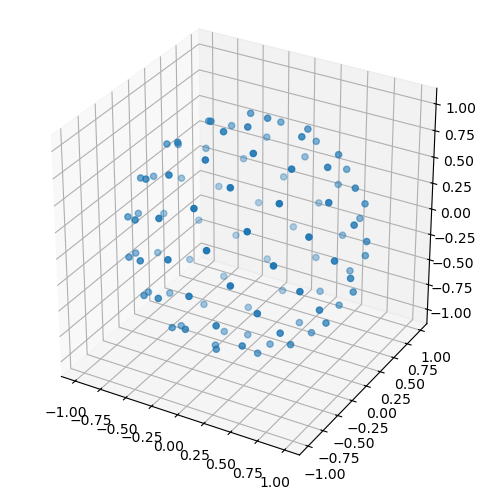

In [4]:
fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(projection='3d')
ax.set_aspect("equal")

N = 100

phi = np.pi * (np.sqrt(5.) - 1.) 
k = np.arange(0, N, dtype=float)
theta = phi * k

z = 1 - (k / float(N - 1)) * 2
radius = np.sqrt(1 - z * z)

x = np.cos(theta) * radius
y = np.sin(theta) * radius

A = np.array([x, y, z]).T
# A = A / la.norm(A, axis=1, ord=2)[:, None]

ax.scatter(*A.T)
plt.show()

In [21]:
dx = 1e-6
K = np.meshgrid(np.arange(0, 40, dtype=float), np.arange(0, 2, dx))

In [22]:
C = np.abs(np.cos(np.pi*(K[0]*np.sqrt(5) - K[1])))
#asort = np.argsort(C, axis=-1)
#C = np.sort(C, axis=-1)

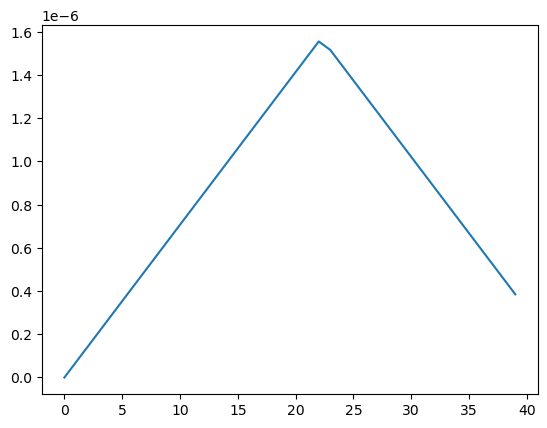

In [23]:
plt.plot(C.min(axis=0))

In [20]:
np.sort(C.min(axis=0))

array([6.12323400e-17, 7.91274356e-09, 3.13868616e-08, 3.92996566e-08,
       6.27737639e-08, 7.06864949e-08, 7.85992618e-08, 1.02073323e-07,
       1.09986118e-07, 1.33460168e-07, 1.41372990e-07, 1.49285780e-07,
       1.72759795e-07, 1.80672636e-07, 2.04146697e-07, 2.12059485e-07,
       2.19972195e-07, 2.43446313e-07, 2.51359154e-07, 2.74833216e-07,
       2.82745979e-07, 2.90658714e-07, 3.14132832e-07, 3.22045627e-07,
       3.45519620e-07, 3.53432476e-07, 3.61345232e-07, 3.84819350e-07,
       3.92732145e-07, 4.16206252e-07, 4.24118973e-07, 4.32031750e-07,
       4.55505811e-07, 4.63418606e-07, 4.86892667e-07, 4.94805466e-07,
       5.02718279e-07, 5.26192283e-07, 5.34105124e-07, 5.57579186e-07,
       5.65491959e-07, 5.73404683e-07, 5.96878812e-07, 6.04791597e-07,
       6.28265704e-07, 6.36178453e-07, 6.44091202e-07, 6.67565331e-07,
       6.75478058e-07, 6.98952108e-07, 7.06864943e-07, 7.14777720e-07,
       7.38251763e-07, 7.46164576e-07, 7.69638751e-07, 7.77551447e-07,
      

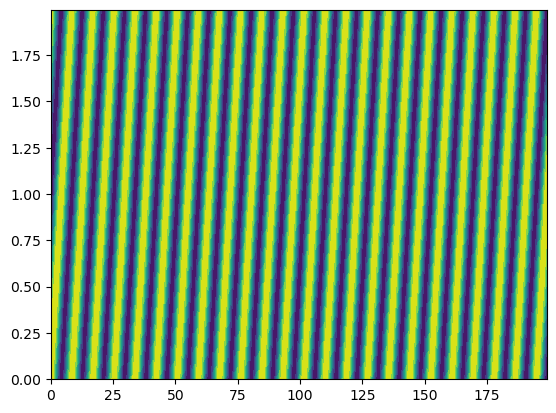

In [89]:
plt.contourf(K[0], K[1], np.cos(np.pi*(K[0]*np.sqrt(5) - K[1])))

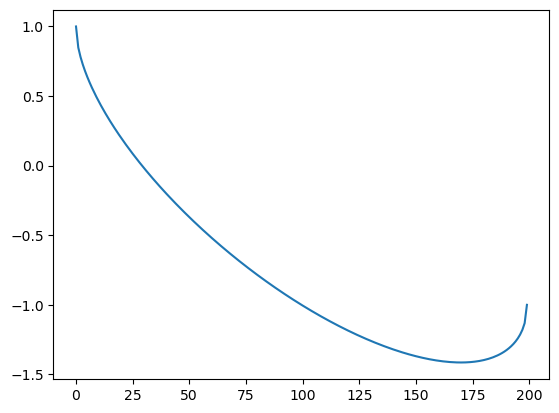

In [78]:
plt.plot(z - radius)

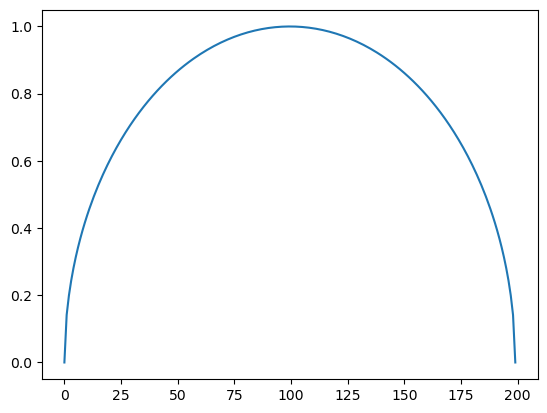

In [76]:
plt.plot(2*np.sqrt(k * (N-1-k)) / (N-1))

In [60]:
s1, s2, s3 = la.svd(A).S
s1

1.826451019193323

In [61]:
S2

33340000.0

In [62]:
np.abs(z*radius).max()

0.49690399499995325

In [63]:
zlzk = N * (N + 1) * (5*N**3 - 9*N**2 - 5*N + 21) / (90 * (N-1)**3)

rlrk = 0.5*(N - 1)*N - N*(N+1)/3 + zlzk

rlrk + zlzk + N*(N-1)/4

20.09259259259259

In [64]:
S2 = N + N*(N-1)/3 # 2*prod_all(A) # = la.norm(A.T @ A, ord='fro')**2
S1 = N

np.sqrt(
    (S1 + np.sqrt(6*S2 - 2*S1**2))/3
)

2.0241461263233265

In [68]:
np.sqrt(
    N/3 + 1 + 1/(N-1)
)

1.8708286933869707

In [47]:
p1 = np.sqrt(2*N)
p2 = np.sqrt(3)
p1 / p2

25.819888974716115

In [46]:
np.sqrt(
    np.sqrt(2 * N**2 - 3 * N)
)

37.59192072979459

In [303]:
run_tests(A, 1000, 1/(3*N), ts_per_min=10_000, n_tests=10_000)

*** , 4 <- 5, 5 <- 6, iteration 0: l = 7, out of n = 600
iteration 1: l = 7, out of n = 600
iteration 2: l = 7, out of n = 600
iteration 3: l = 7, out of n = 600
iteration 4: l = 7, out of n = 600
iteration 5: l = 7, out of n = 600
iteration 6: l = 7, out of n = 600
iteration 7: l = 7, out of n = 600
iteration 8: l = 7, out of n = 600
iteration 9: l = 7, out of n = 600
iteration 10: l = 7, out of n = 600
iteration 11: l = 7, out of n = 600
iteration 12: l = 7, out of n = 600
iteration 13: l = 7, out of n = 600
iteration 14: l = 7, out of n = 600
iteration 15: l = 7, out of n = 600
iteration 16: l = 7, out of n = 600
iteration 17: l = 7, out of n = 600
iteration 18: l = 7, out of n = 600
iteration 19: l = 7, out of n = 600
iteration 20: l = 7, out of n = 600
iteration 21: l = 7, out of n = 600
iteration 22: l = 7, out of n = 600
iteration 23: l = 7, out of n = 600
iteration 24: l = 7, out of n = 600
iteration 25: l = 7, out of n = 600
iteration 26: l = 7, out of n = 600
iteration 27: l 

In [11]:
dx = 5e-3
u = np.arange(0, np.pi, dx)
v = np.arange(0, 2*np.pi, dx)
denum = np.abs(np.sin(v)) + np.abs(np.cos(v))
X = np.vstack(list(map(np.ravel, 
                       [np.outer(np.cos(u)**2, np.sin(v) / denum) , 
                        np.outer(np.sin(u)**2, np.sin(v) / denum), 
                        np.outer(np.ones(np.size(u)), np.cos(v) / denum)]))).T

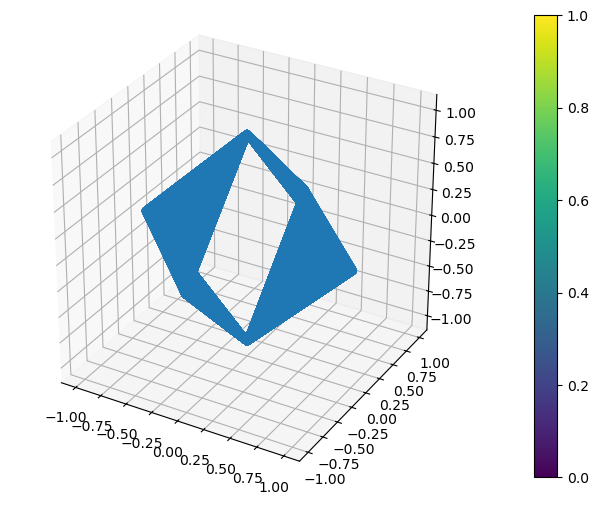

In [12]:
fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(projection='3d')
ax.set_aspect("equal")
cbar = ax.scatter(*X.T)
plt.colorbar(cbar)
plt.show()

In [15]:
np.abs(X).sum(axis=1).std()

8.00288833761457e-17

In [51]:
class Symmetric(nn.Module):
    def forward(self, X):
        _, n = X.shape
        space = X.sign() * torch.arange(1, n+1, dtype=X.dtype, device=X.device, requires_grad=False)[torch.argsort(X, stable=True)[0]]
        return X + space / n

In [52]:
m = nn.Linear(5, 1)
P.register_parametrization(m, "weight", Symmetric())
m.weight

tensor([[-0.8108, -0.6618, -0.5522,  0.9527,  1.3548]], grad_fn=<AddBackward0>)

In [26]:
sma = nn.AvgPool1d(kernel_size=2, stride = 1)
kal = torch.arange(0,10,1,dtype=torch.float).view(1,-1)
kal, kal.shape

(tensor([[0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 10]))

In [25]:
sma(kal) * 2

tensor([[ 1.,  3.,  5.,  7.,  9., 11., 13., 15., 17.]])

In [23]:
kal.shape

torch.Size([1, 1, 10])

In [35]:
(nn.functional.avg_pool1d(kal, 2, 1, 1, count_include_pad=True) * 2)

tensor([[ 0.,  1.,  3.,  5.,  7.,  9., 11., 13., 15., 17.,  9.]])

In [7]:
# Create a tensor of complex numbers
complex_tensor = torch.tensor([1+2j, 3-1j, 1+1j, 2+0j], dtype=torch.complex64)


# Sort the complex tensor along the default (last) dimension
_, indices = torch.sort(complex_tensor.imag, stable=True)
sorted_tensor = complex_tensor[indices]
_, indices = torch.sort(sorted_tensor.real, stable=True)
sorted_tensor = sorted_tensor[indices]
# Sort in descending order
sorted_tensor

tensor([1.+1.j, 1.+2.j, 2.+0.j, 3.-1.j])

In [48]:
A = np.random.random((10, 5))
la.svd(A, ).S[0]

3.7322126936714177

In [46]:
np.sqrt(np.diag(A.T @ A))

array([11.5758369 , 10.67707825,  9.43398113,  8.1240384 ,  9.8488578 ])

In [15]:
import numpy as np
from numpy import linalg as la
from scipy.spatial import distance

from matplotlib import pyplot as plt
from matplotlib import cm, colors

%matplotlib inline

In [16]:
def stab_op(s, t, p):
    x1 = np.power(0.5 * np.abs(s-t), p)
    x2 = np.sign(s) * np.power(np.abs(s), 1-p)
    return x1 * x2
    

In [17]:
n = 1200
c = [1, -1]#[::-1]

l1, u1 = -20, 20
l2, u2 = -20, 20

x = np.linspace(l1, u1, n)
y = np.linspace(l2, u2, n)
x, y = np.meshgrid(x, y)

d = np.maximum(np.abs(x - c[0]), np.abs(y - c[1]))
p = 0.5

f = np.abs(stab_op(x, y, p) - stab_op(c[0], c[1], p)) / d
#f = stab_op(x, y, p)
xs = np.array([x[f == np.nanmax(f)], y[f == np.nanmax(f)]])

In [19]:
d

array([[21.        , 20.96663887, 20.93327773, ..., 19.        ,
        19.        , 19.        ],
       [21.        , 20.96663887, 20.93327773, ..., 18.96663887,
        18.96663887, 19.        ],
       [21.        , 20.96663887, 20.93327773, ..., 18.93327773,
        18.96663887, 19.        ],
       ...,
       [21.        , 20.96663887, 20.93327773, ..., 20.93327773,
        20.93327773, 20.93327773],
       [21.        , 20.96663887, 20.96663887, ..., 20.96663887,
        20.96663887, 20.96663887],
       [21.        , 21.        , 21.        , ..., 21.        ,
        21.        , 21.        ]])

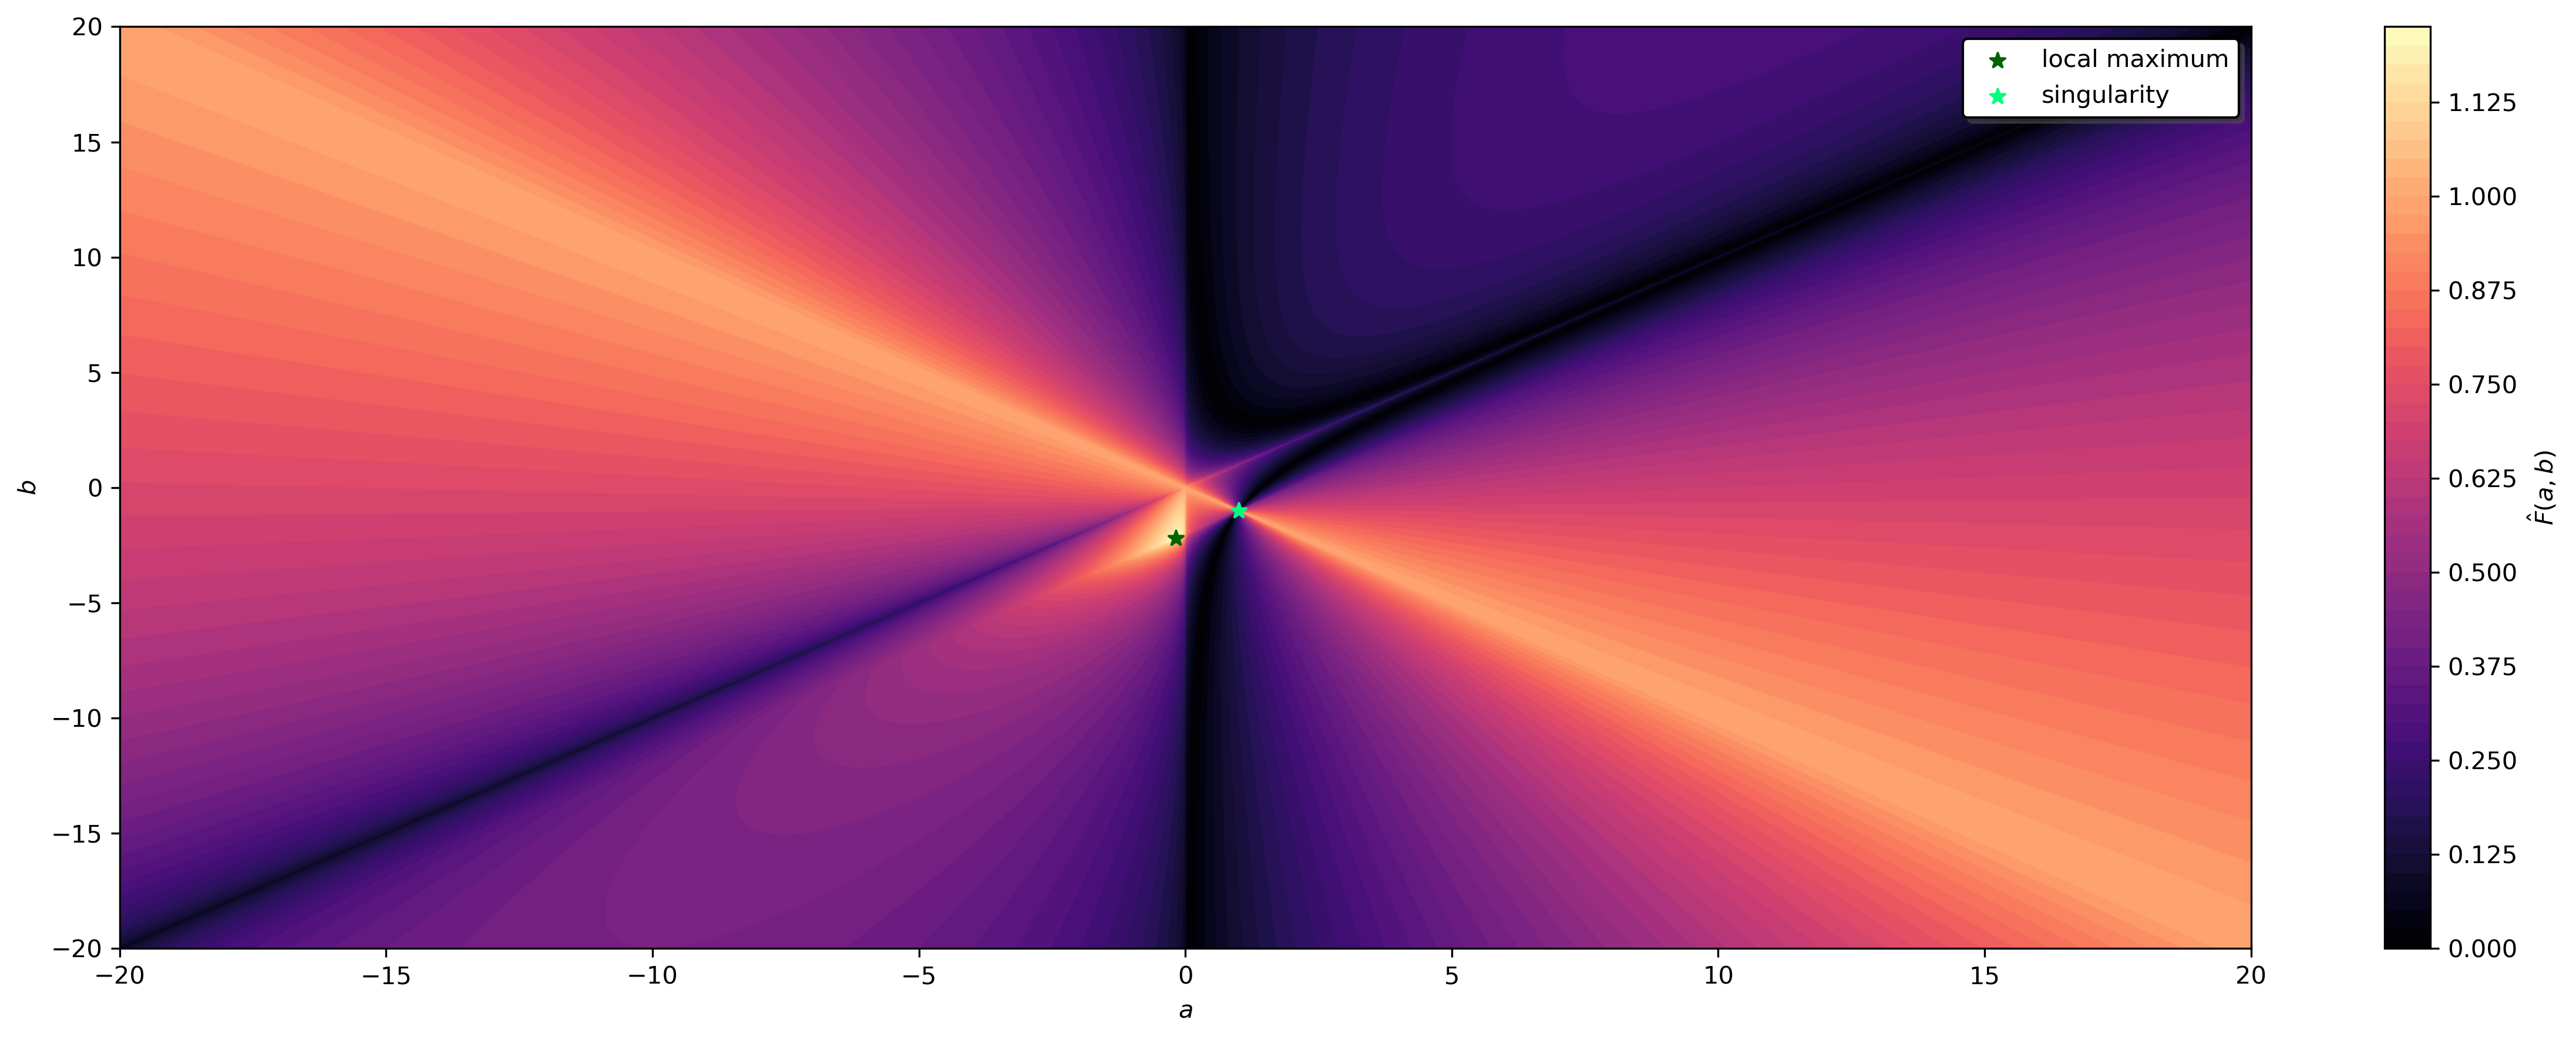

In [14]:
plt.figure(figsize=(16, 6), dpi=300)
cmap = plt.contourf(x, y, f, levels=50, cmap='magma')
plt.scatter(*xs[:, None], marker='*', label='local maximum', c='darkgreen', s=40)
plt.scatter([1], [-1], marker='*', label='singularity', c='springgreen', s=40)
plt.xlabel(r'$a$', )#fontsize=15)
plt.ylabel(r'$b$', )#fontsize=15)
cbar = plt.colorbar(cmap, )
cbar.set_label(label=r'$\hat{F}(a, b)$', )#fontsize=15, ) 
plt.legend(shadow=True, fancybox=True, edgecolor='k')
plt.tight_layout()
plt.savefig("wsop_bounds.pdf", format='pdf')
plt.show()

In [211]:
np.nanmax(f) - (np.sqrt(3 - 2*np.sqrt(2)) + 1) / (4 - 2*np.sqrt(2))

-1.2158118956051567e-09

In [212]:
x[f == np.nanmax(f)], y[f == np.nanmax(f)] 

(array([-0.17160133]), array([-2.17160133]))

In [213]:
np.maximum(np.abs(x[f == np.nanmax(f)] - c[0]), np.abs(y[f == np.nanmax(f)] - c[1]))

array([1.17160133])

In [93]:
x = np.linspace(l1, u1, n)
f = stab_op(x + 2, x, p) / np.maximum(np.abs(x - c[0]), np.abs(x - c[1]))
f.max()

1.0666991514978563